<a href="https://colab.research.google.com/github/springboardmentorLive/Reality_AI/blob/bhaskar/work_modules.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#work--6

from PIL import Image
from PIL import ImageDraw
img = Image.open('/content/IMG_20230819_171116.jpg')
draw = ImageDraw.Draw(img)

draw.text((500,500),"om nama shivaya",fill=(0,155,125))

img.save("output_image_with_text.jpg")
img.show()


resize_img = img.resize((200,200))

rotate_img = img.rotate(90)
rotate_img.save("rotated_img.jpg")
img.show()


grayscal_img = img.convert('L')
grayscal_img.save("grayscale_img.jpg")

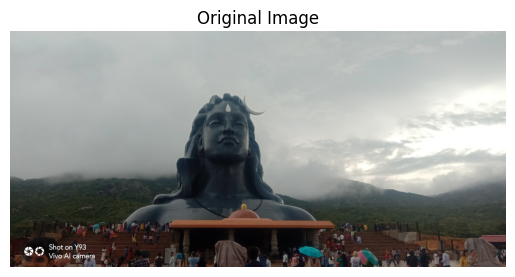

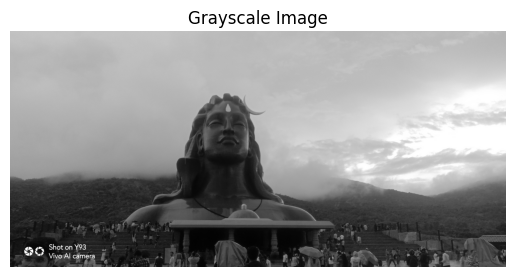

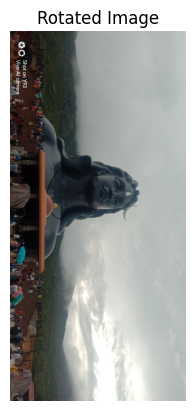

In [ ]:
import cv2
import matplotlib.pyplot as plt

# ✅ Read the image
image = cv2.imread("/content/IMG_20230819_171116.jpg")

# ✅ Check if image loaded
if image is None:
    print("Image not found!")
else:
    # ✅ Convert BGR to RGB for correct color display
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # ✅ Convert to Grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # ✅ Rotate the Image (90 degrees clockwise)
    rotated = cv2.rotate(image_rgb, cv2.ROTATE_90_CLOCKWISE)


    plt.figure()
    plt.title("Original Image")
    plt.imshow(image_rgb)
    plt.axis("off")
    plt.show()


    plt.figure()
    plt.title("Grayscale Image")
    plt.imshow(gray, cmap='gray')
    plt.axis("off")
    plt.show()


    plt.figure()
    plt.title("Rotated Image")
    plt.imshow(rotated)
    plt.axis("off")
    plt.show()

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

classes = ["aeroplane","bicycle","birds","boat"]

net = cv2.dnn.readNetFromDarknet("deploy.prototext","mobilenet_iter_73000.caffemodel")

image = cv2.imread("/content/IMG_20230819_171116.jpg")

h,w = image.shape[:2]

blob = cv2.dnn.blobFromImage((image,1,(300,300)),0.007843,(300,300),127.5)

net.setInput(blob)
detections = net.forward()

object_count = 0

for i in range(detections.shape[2]):
    confidence = detections[0,0,i,2]
    if confidence > 0.5:
        class_id = int(detections[0,0,i,1])
        label = classes[class_id]
        box = detections[0,0,i,3:7]*np.array([w,h,w,h])
        if label in classes:
            object_count += 1
print("object count:",object_count)
image =cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
plt.figure()
plt.imshow(image)
plt.show()


error: OpenCV(4.12.0) /io/opencv/modules/dnn/src/darknet/darknet_importer.cpp:210: error: (-212:Parsing error) Failed to open NetParameter file: deploy.prototext in function 'readNetFromDarknet'


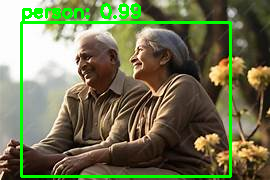

In [ ]:
import torch
import torchvision
from torchvision.transforms import functional as F
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights
import cv2
from google.colab.patches import cv2_imshow

# ------------------------------
# Load model with updated API
# ------------------------------
weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=weights)
model.eval()

# Load COCO labels
labels = weights.meta["categories"]

# ------------------------------
# Load image
# ------------------------------
img_path = "/content/OIP (1).jpg"   # change this
image = cv2.imread(img_path)
orig = image.copy()

# Convert to RGB and tensor
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
tensor = F.to_tensor(image_rgb)
tensor = tensor.unsqueeze(0)

# ------------------------------
# Run detection
# ------------------------------
with torch.no_grad():
    predictions = model(tensor)

boxes = predictions[0]["boxes"]
scores = predictions[0]["scores"]
classes = predictions[0]["labels"]

# ------------------------------
# Draw boxes
# ------------------------------
for box, score, cls in zip(boxes, scores, classes):
    if score < 0.7:  # confidence threshold increased to 0.7
        continue

    x1, y1, x2, y2 = box.int().tolist()
    label = f"{labels[cls]}: {score:.2f}"

    cv2.rectangle(orig, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(orig, label, (x1, y1 - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

# ------------------------------
# Show result
# ------------------------------
cv2_imshow(orig)


In [ ]:
person_count = 0
for cls in classes:
    if labels[cls] == 'person':
        person_count += 1

print(f"Number of persons detected: {person_count}")

Number of persons detected: 5


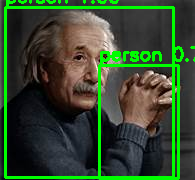

Number of persons detected: 2


In [ ]:
import torch
import torchvision
from torchvision.transforms import functional as F
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights
import cv2
from google.colab.patches import cv2_imshow

# Load model
weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=weights)
model.eval()

labels = weights.meta["categories"]

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Load image
img_path = "/content/OIP (3).jpg"   # put your image in Colab files
image = cv2.imread(img_path)
orig = image.copy()

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
tensor = F.to_tensor(image_rgb).unsqueeze(0).to(device)

# Run detection
with torch.no_grad():
    preds = model(tensor)

boxes = preds[0]["boxes"].cpu()
scores = preds[0]["scores"].cpu()
classes = preds[0]["labels"].cpu()

# Count persons
person_count = 0

# Draw bounding boxes
for box, score, cls in zip(boxes, scores, classes):
    if score < 0.3:
        continue

    x1, y1, x2, y2 = box.int().tolist()
    label_name = labels[cls]

    # counting persons
    if label_name == "person":
        person_count += 1

    label = f"{label_name} {score:.2f}"
    cv2.rectangle(orig, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(orig, label, (x1, y1 - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

# Show result in Colab
cv2_imshow(orig)

# Print number of persons detected
print("Number of persons detected:", person_count)


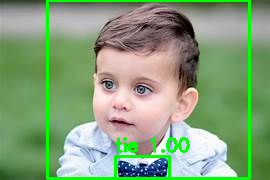

Number of persons detected: 1


In [ ]:
import torch
import torchvision
from torchvision.transforms import functional as F
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights
import cv2
from google.colab.patches import cv2_imshow

# Load model
weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=weights)
model.eval()

labels = weights.meta["categories"]

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Load image
img_path = "/content/OIP (4).jpg"   # put your image in Colab files
image = cv2.imread(img_path)
orig = image.copy()

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
tensor = F.to_tensor(image_rgb).unsqueeze(0).to(device)

# Run detection
with torch.no_grad():
    preds = model(tensor)

boxes = preds[0]["boxes"].cpu()
scores = preds[0]["scores"].cpu()
classes = preds[0]["labels"].cpu()

# Count persons
person_count = 0

# Draw bounding boxes
for box, score, cls in zip(boxes, scores, classes):
    if score < 0.3:
        continue

    x1, y1, x2, y2 = box.int().tolist()
    label_name = labels[cls]

    # counting persons
    if label_name == "person":
        person_count += 1

    label = f"{label_name} {score:.2f}"
    cv2.rectangle(orig, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(orig, label, (x1, y1 - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

# Show result in Colab
cv2_imshow(orig)

# Print number of persons detected
print("Number of persons detected:", person_count)
